<a href="https://colab.research.google.com/github/metarun/Micrograd/blob/main/micrograd.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [32]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [33]:
def f(x):
  return 3*x**2 - 4*x + 5

In [34]:
f(3)

20

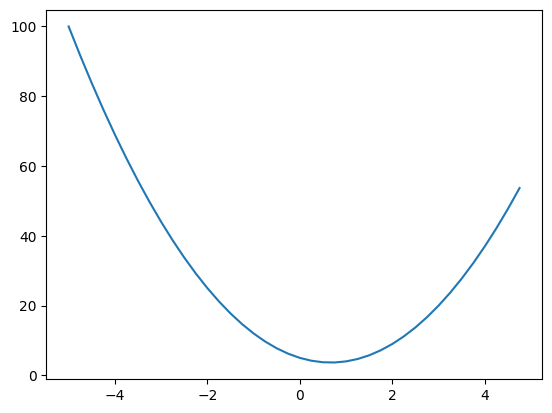

In [35]:
xs = np.arange(-5,5,.25)
ys = f(xs)
plt.plot(xs,ys)
plt.show()

In [36]:
h = 0.001
x = 3
(f(x+h) - f(x))/h

14.00300000000243

In [37]:
#6x - 4 dervative of f(x)
6*3- 4

14

In [38]:
x = -3
6*(-3) - 4

-22

In [39]:
h = 0.001
x = -3
(f(x+h) - f(x))/h

-21.996999999998934

In [40]:
#complex

a = 2.0
b = -3.0
c = 10

d=a*b + c
print(d)

4.0


In [41]:
h = 0.001
#complex

a = 2.0
b = -3.0
c = 10

# Devrivative wrt a
d1 =a*b + c
a +=  h
d2 =a*b + c
print('d1', d1)
print('d2', d2)
print('Slope', (d2-d1)/h)


d1 4.0
d2 3.997
Slope -3.0000000000001137


In [42]:
class Value:
  def __init__(self,data, _children=(), op='', label='', derivative = ''):
    self.data = data
    self.grad = 0 # By default we assume that changing this value does not change the output from the last layer.
    self._prev = set(_children)
    self._op = op
    self.label = label
    self.derivative = derivative


  def __repr__(self):
    return f"Value(data={self.data})"

  def __add__(self,other):
    return Value(self.data + other.data, (self,other),'+')

  def __mul__(self,other):
    return Value(self.data * other.data, (self,other),'*')

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self,), 'tanh')
    return out

In [43]:
a = Value(2.0) # a.data = 2
b = Value(3.0) # b.data = 3
a + b # result.data = 5 --> __repr__(result) ==> Value(data=5)


Value(data=5.0)

In [44]:
a = Value(2.0)  # a.data = 2
b = Value(-3.0)  # b.data = 3
c = Value(10)   # c.data = 10
d = a + b*c # result.data = 32 --> __repr__(result) ==> Value(data=32)
d

Value(data=-28.0)

In [45]:
d._op, d._prev

('+', {Value(data=-30.0), Value(data=2.0)})

In [46]:
# Visualisatio
#!pip install graphviz
from graphviz import Digraph

In [47]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root, format='svg', rankdir='LR'):
    """
    format: png | svg | ...
    rankdir: TB (top to bottom graph) | LR (left to right)
    """
    assert rankdir in ['LR', 'TB']
    nodes, edges = trace(root)
    dot = Digraph(format=format, graph_attr={'rankdir': rankdir}) #, node_attr={'rankdir': 'TB'})

    for n in nodes:
        dot.node(name=str(id(n)), label = "{%s | %s | data %.4f | grad %.4f  }" % (n.label,n.derivative, n.data, n.grad), shape='record')
        if n._op:
            dot.node(name=str(id(n)) + n._op, label=n._op)
            dot.edge(str(id(n)) + n._op, str(id(n)))

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [48]:
a = Value(2.0, label= 'a') # a.data = 2
b = Value(-3.0) ; b.label= 'b' # b.data = 3
c = Value(10); c.label= 'c'
e = a*b; e.label= 'e'
d = e + c ; d.label= 'd'
f = Value(-2.0); f.label= 'f'
L = d*f; L.label= 'L'
L

Value(data=-8.0)

In [49]:
# draw_dot(L)

In [50]:
def lol():
  h = 0.001
  h = Value(h)


  a = Value(2.0, label= 'a') # a.data = 2
  b = Value(-3.0) ; b.label= 'b' # b.data = 3
  c = Value(10); c.label= 'c'
  e = a*b; e.label= 'e'
  d = e + c ; d.label= 'd'
  f = Value(-2.0); f.label= 'f'
  L1 = d*f; L1.label= 'L1'



  a = Value(2.0, label= 'a') # a.data = 2
  b = Value(-3.0) ; b.label= 'b' # b.data = 3
  c = Value(10); c.label= 'c'
  # c = c+h
  e = a*b; e.label= 'e'
  e = e+h
  d = e + c ; d.label= 'd'
  # d=  d+ h
  f = Value(-2.0); f.label= 'f'
  # f= f+h
  L2 = d*f;
  # L2 = L2 + h
  # L2 = L2

  return (L2.data - L1.data) / h.data

In [51]:
lol()

-2.000000000000668

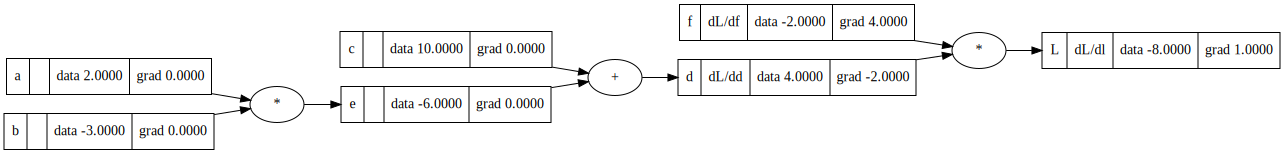

In [52]:
L.grad = 1
L.derivative= 'dL/dl'
d.grad = -2
d.derivative= 'dL/dd'
f.grad = 4
f.derivative= 'dL/df'
draw_dot(L)

In [53]:
# we need to find now influance of C on L so dl/dc
# dl/dc = (dd / dc ) * ( dl / dd )

# dd / dc
# d= c + e

# dd/dc = f(x+h) - f(x) / h
# f(x) = c + e
# f(x+h) = c + h + e

# dd/dc= ( c + h + e) -  (c + e) / h
# dd/dc = h / h
# dd/dc = 1

# dl/dc = 1 * (dl / dd)
# dl / dc = 1 * -2.0
# dl / dc = .2.0

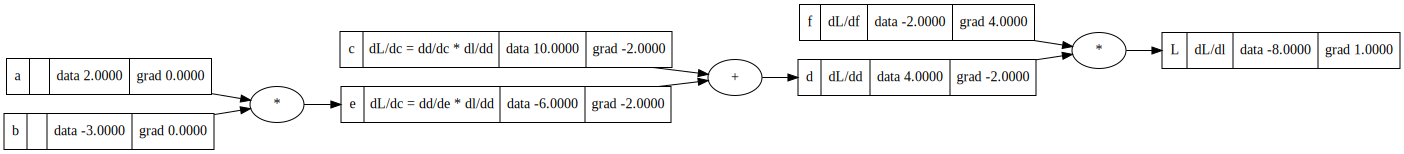

In [54]:
c.grad = -2
c.derivative = 'dL/dc = dd/dc * dl/dd'
e.grad = -2
e.derivative = 'dL/dc =  dd/de * dl/dd'
draw_dot(L)

In [55]:
# we need to find now influance of b on L so db/dc
# dl/db = (de / db ) * ( dL / de )

# de / db
# e = a * b

# de / db = f(x+h) - f(x) / h
# f(x) = a * b
# f(x+h) = a * (b + h)

# de/db= ( ab + bh -  (ab) / h
# de/db = bh / h
# de/db = b

# dl/db = (de / db ) * ( dL / de )
# dl/db = -3.0 * (dL / de)
# dl/db = -3.0 * -2.0
# dl/db = 6.0

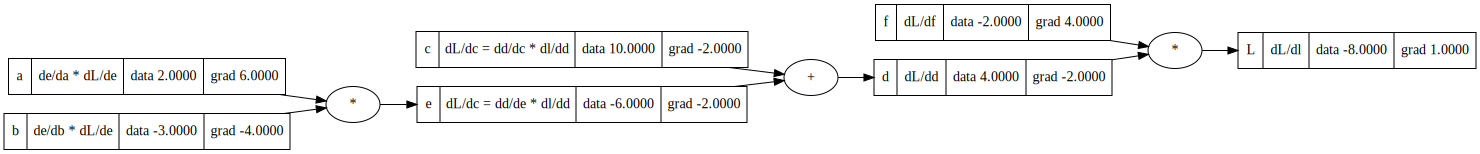

In [56]:
b.grad = 2.0 * -2.0
b.derivative = 'de/db  * dL/de'
a.grad = -3.0 * -2.0
a.derivative = 'de/da  * dL/de'
draw_dot(L)


In [57]:
# now lets update the data with learning rate and its gradient
L

Value(data=-8.0)

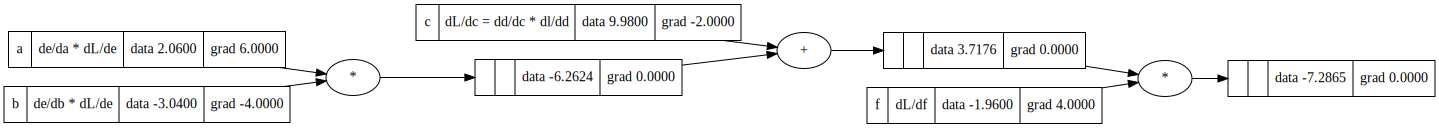

In [58]:

h = .01
a.data += h * a.grad
b.data += h * b.grad
c.data += h * c.grad
f.data += h * f.grad

e=a*b
d = e+c
L=d*f
draw_dot(L)

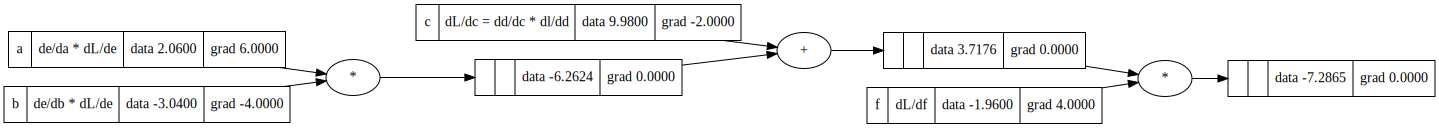

In [59]:
draw_dot(L)

In [60]:
# create a nueron with whatever we have built above

![](https://cs231n.github.io/assets/nn1/neuron_model.jpeg)

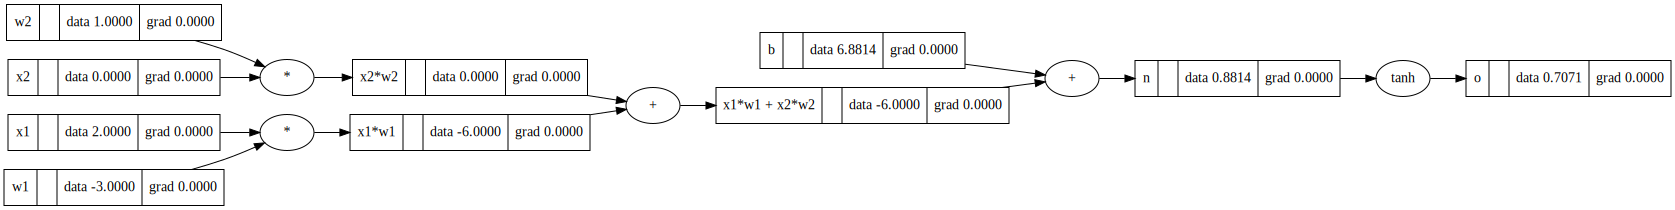

In [61]:
#Input x1 and x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# Weight w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

#bias b
b = Value(6.8813735870195432, label='b')

#x1*w1
x1w1 = x1*w1; x1w1.label = 'x1*w1'
#x2*w2
x2w2 = x2*w2; x2w2.label = 'x2*w2'

#x1w1+x2w2
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'

o = n.tanh()
o.label = 'o'

draw_dot(o)

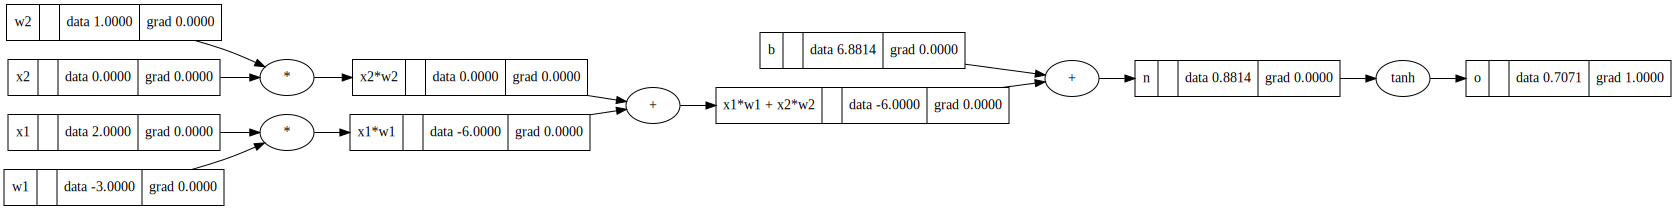

In [69]:
draw_dot(o)

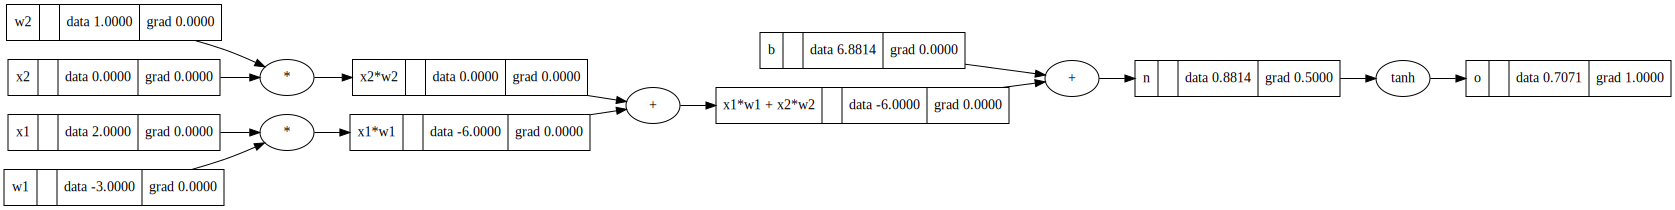

In [75]:
o.grad=1
# o = tanh(n)
# do/dn = d tanh(n) / dn
# do/dn = 1 - tanh(n)**2
# do/dn = 1 - o **2 ==> o = tanh(n)
#o =  o.data

n.grad = 1 - (o.data)**2
draw_dot(o)